# 1 month salt budget test for ACCESS-OM2-01

In [1]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [2]:
lat_slice = slice(-79,-59)

# Importing data
paths_2 = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia-expt-c085baf0/output000/ocean/ocean.nc'))
paths_1 = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia-expt-c085baf0/output000/ocean/ocean_month.nc'))

In [3]:
paths_1

array(['/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia-expt-c085baf0/output000/ocean/ocean_month.nc'],
      dtype='<U103')

In [4]:
# Time variant variables
def preprocess_1(ds):
    ds = ds[['pme_river','runoff','evap',]].sel(yt_ocean=lat_slice)
    return ds

def preprocess_2(ds):
    ds = ds[['salt','salt_advection','salt_submeso','salt_tendency','salt_vdiffuse_impl','salt_nonlocal_KPP','salt_rivermix','salt_eta_smooth']].sel(yt_ocean=lat_slice)
    return ds

#data_1 = xr.open_mfdataset(paths_1, preprocess = preprocess_1, chunks = 'auto')
data_2 = xr.open_mfdataset(paths_2, preprocess = preprocess_2, chunks = 'auto',decode_times=False)

In [5]:
data_2

<xarray.Dataset> Size: 3GB
Dimensions:             (time: 1, st_ocean: 75, yt_ocean: 460, xt_ocean: 3600)
Coordinates:
  * time                (time) float64 8B 15.5
  * st_ocean            (st_ocean) float64 600B 0.5413 1.681 ... 5.709e+03
  * yt_ocean            (yt_ocean) float64 4kB -79.0 -78.95 ... -59.08 -59.03
  * xt_ocean            (xt_ocean) float64 29kB -279.9 -279.8 ... 79.85 79.95
Data variables:
    salt                (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_advection      (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_submeso        (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_tendency       (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_vdiffuse_impl  (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_nonlocal_KPP   (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_rivermix       (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_eta_smooth     (time, yt_ocean, xt_ocean) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
Attributes:
    filename:   ocean.nc
    title:      ACCESS-OM2-01
    grid_type:  mosaic
    grid_tile:  1
    history:    20260223T0208Z: /g/data/ik11/inputs/access-om2/bin/mppnccombi...

In [30]:
lhs_salt = {
    'salt_tendency': data_2.salt_tendency
}

rhs_salt = {
    # Advection
    'advection': data_2.salt_advection,
    'submeso': data_2.salt_submeso,

    # Diffusion / mixing + Surface & boundary forcing
    'vertical_diff': data_2.salt_vdiffuse_impl, # this includes surface salt flux
    'nonlocal_KPP': data_2.salt_nonlocal_KPP,
    'river_mix': data_2.salt_rivermix,
    'eta_smooth': data_2.salt_eta_smooth, # surface smoother for salt
}

In [31]:
data_2.salt_eta_smooth

<xarray.DataArray 'salt_eta_smooth' (time: 1, yt_ocean: 460, xt_ocean: 3600)> Size: 7MB
dask.array<getitem, shape=(1, 460, 3600), dtype=float32, chunksize=(1, 460, 3600), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) float64 8B 15.5
  * yt_ocean  (yt_ocean) float64 4kB -79.0 -78.95 -78.91 ... -59.08 -59.03
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
Attributes:
    long_name:      surface smoother for salt
    units:          kg/(sec*m^2)
    valid_range:    [-100000.  100000.]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT

At the moment taking `time`=0 to just look at first month - but I'm unsure this is still giving me the right evolution over time that I am looking for.

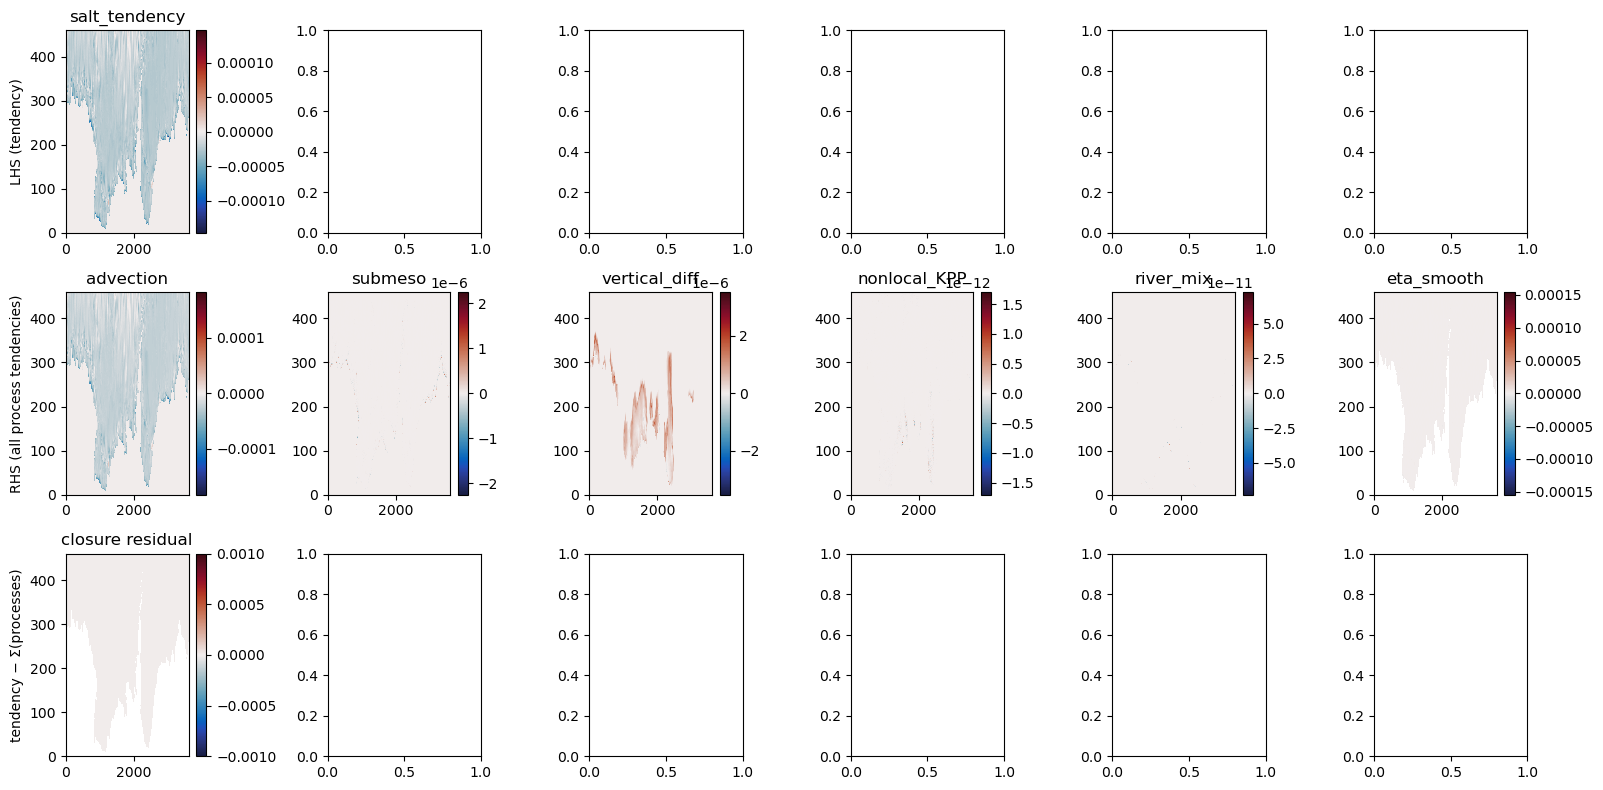

In [46]:
zdim = 'st_ocean'  # MOM5 vertical grid dimension

fig, ax = plt.subplots(
    figsize=(16, 8),
    nrows=3,
    ncols=max(len(lhs_salt), len(rhs_salt))
)
ax = ax.reshape(3, -1)  # flatten for consistent indexing

# -----------------------
# LHS terms
# -----------------------
for i, (name, da) in enumerate(lhs_salt.items()):
    da2d = da.sum(zdim).squeeze()
    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)
    da2d = da2d.compute()
    vmax = np.nanmax(np.abs(da2d))
    im = ax[0, i].pcolormesh(da2d, cmap=cm.cm.balance,vmax = vmax,vmin = -vmax)
    plt.colorbar(im, ax=ax[0, i])
    ax[0, i].set_title(name)

# -----------------------
# RHS terms
# -----------------------
for i, (name, da) in enumerate(rhs_salt.items()):
    if zdim in da.dims:
        da2d = da.sum(zdim)
    else:
        da2d = da
        
    da2d = da2d.squeeze()
    
    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)
    da2d = da2d.compute()
    vmax = np.nanmax(np.abs(da2d))
    im = ax[1, i].pcolormesh(da2d,cmap=cm.cm.balance,vmax = vmax,vmin = -vmax)
    plt.colorbar(im, ax=ax[1, i])
    ax[1, i].set_title(name)

# -----------------------
# Closure residual
# -----------------------
# lhs_total = data_2.salt_tendency

# rhs_total = (
#     data_2.salt_advection
#     + data_2.salt_submeso
#     + data_2.salt_vdiffuse_impl
#     + data_2.salt_nonlocal_KPP
#     + data_2.salt_rivermix
#     + data_2.salt_eta_smooth
# )

# residual = (lhs_total - rhs_total).sum(zdim).squeeze()

# Sum only 3D terms
lhs_col = lhs_total.sum(zdim)

rhs_col = (
    data_2.salt_advection.sum(zdim)
    + data_2.salt_submeso.sum(zdim)
    + data_2.salt_vdiffuse_impl.sum(zdim)
    + data_2.salt_nonlocal_KPP.sum(zdim)
    + data_2.salt_rivermix.sum(zdim)
)

# Now add the 2D correction ONCE
rhs_col = rhs_col + data_2.salt_eta_smooth

residual = lhs_col - rhs_col

if 'time' in residual.dims:
    residual = residual.isel(time=0)

residual = residual.compute()
vmax = np.abs(residual).max()

im = ax[2, 0].pcolormesh(
    residual, cmap=cm.cm.balance, vmin=-0.001, vmax=0.001
)
plt.colorbar(im, ax=ax[2, 0])
ax[2, 0].set_title('closure residual')


# -----------------------
# Row labels
# -----------------------
ax[0, 0].set_ylabel('LHS (tendency)')
ax[1, 0].set_ylabel('RHS (all process tendencies)')
ax[2, 0].set_ylabel('tendency − Σ(processes)')

plt.tight_layout()


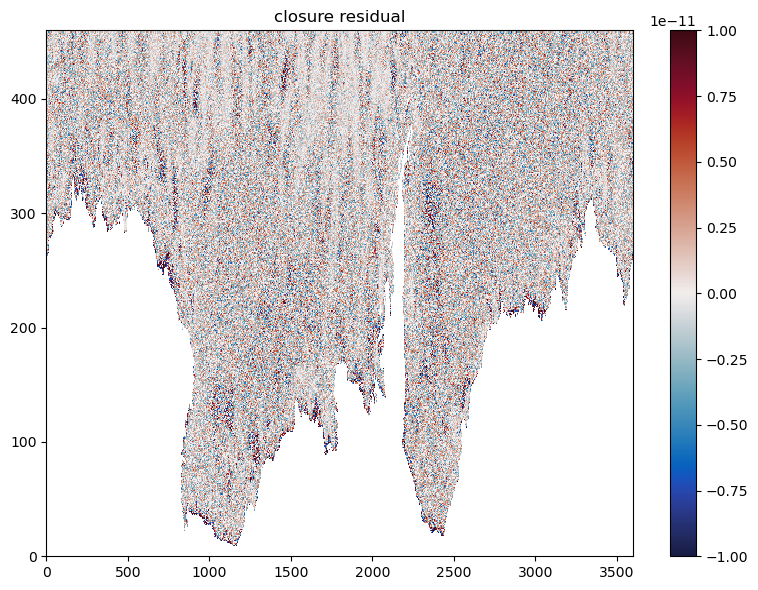

In [57]:
# Plotting just the residual

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.pcolormesh(
    residual,
    cmap=cm.cm.balance,
    vmin=-1e-11,
    vmax=1e-11
)

plt.colorbar(im, ax=ax)
ax.set_title('closure residual')

plt.tight_layout()

#### Checking if we have closure:   
We are told that for the budget to be considered “closed” the difference between the LHS and RHS should be approximately 12 orders of magnitude smaller than the contributing terms. 

In [48]:
closure = lhs_total - rhs_total

In [49]:
closure.max().compute()

<xarray.DataArray ()> Size: 4B
array(0.00015449, dtype=float32)

In [50]:
closure.min().compute()

<xarray.DataArray ()> Size: 4B
array(-0.00012678, dtype=float32)

In [51]:
closure

<xarray.DataArray (time: 1, st_ocean: 75, yt_ocean: 460, xt_ocean: 3600)> Size: 497MB
dask.array<sub, shape=(1, 75, 460, 3600), dtype=float32, chunksize=(1, 75, 460, 720), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) float64 8B 15.5
  * st_ocean  (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * yt_ocean  (yt_ocean) float64 4kB -79.0 -78.95 -78.91 ... -59.08 -59.03
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95

In [52]:
# Note residual = (lhs_total - rhs_total).sum(zdim).squeeze()
residual

<xarray.DataArray (yt_ocean: 460, xt_ocean: 3600)> Size: 7MB
array([[           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       ...,
       [ 0.0000000e+00,  3.6379788e-12, -1.8189894e-12, ...,
         3.6379788e-12,  1.8189894e-12,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  3.6379788e-12,  0.0000000e+00],
       [-7.2759576e-12,  0.0000000e+00,  1.8189894e-12, ...,
         3.6379788e-12, -1.8189894e-12, -1.8189894e-12]], dtype=float32)
Coordinates:
  * yt_ocean  (yt_ocean) float64 4kB -79.0 -78.95 -78.91 ... -59.08 -59.03
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
    time      float64 8B 15.5

In [53]:
residual.max().compute()

<xarray.DataArray ()> Size: 8B
array(1.16415322e-10)
Coordinates:
    time     float64 8B 15.5

In [54]:
residual.min().compute()

<xarray.DataArray ()> Size: 8B
array(-1.34605216e-10)
Coordinates:
    time     float64 8B 15.5

So maybe closed???

## Attempting to close the budget

In [45]:
data_2.salt_eta_smooth.min().compute()

<xarray.DataArray 'salt_eta_smooth' ()> Size: 4B
array(-0.00015449, dtype=float32)

In [41]:
# residual = (lhs_total - rhs_total).sum(zdim).squeeze()

test_1 = residual + data_2.salt_eta_smooth

In [42]:
test_1.max().compute()

<xarray.DataArray ()> Size: 4B
array(0.00478912, dtype=float32)

In [43]:
test_1.min().compute()

<xarray.DataArray ()> Size: 4B
array(-0.00393025, dtype=float32)

## Checking ice thickness issue using old experiments

In [26]:
sit_map_C = xr.open_dataarray('/g/data/g40/kc5856/thesis_figures/data_files/ice_thickness_map_cont_prescribed_ACCESS.nc', chunks = 'auto')

In [27]:
sit_map_C.max().load()

<xarray.DataArray 'hi_m' ()> Size: 4B
array(14.42856, dtype=float32)

In [28]:
sit_map_C.min().load()

<xarray.DataArray 'hi_m' ()> Size: 4B
array(0., dtype=float32)